# Task 1.1 — Data Preparation and Validation Pipeline
**Unsupervised Learning Project 2025/2026 — Hotel Booking Demand**

## RQ1 — Segmentation Question

**Question:** Can we segment hotel guests into distinct travel-purpose profiles — particularly distinguishing business from leisure travellers — using only booking-time features such as lead time, length of stay, number of adults, and seasonality, in order to support hotel revenue management and tailored pricing strategies?

**Unit of analysis:** Each row represents one booking record (not a unique guest — the same guest may appear in multiple rows).

**Why clustering?** There are no predefined labels for guest travel purpose in the booking data. Clustering is appropriate because: (1) we operate in a fully unsupervised setting; (2) it discovers natural groupings empirically from booking patterns rather than forcing data into assumed business/leisure categories; and (3) it can reveal micro-segments with distinct behaviours that a simple binary classification would miss. To avoid leakage, only features known at or before booking time are used as clustering inputs.

## Data Documentation

- **Source:** Course release v1 — `hotel_bookings_course_release_v1.csv`
- **Original:** Kaggle — [jessemostipak/hotel-booking-demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand/data)
- **Reference:** António, N., de Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, 22, 41–49. https://doi.org/10.1016/j.dib.2018.11.126
- **License:** CC0 1.0 Public Domain (as stated in the course release)
- **What each row represents:** One hotel booking record (one stay or cancellation)
- **Time span:** Arrivals between July 2015 and August 2017, across two hotels (City Hotel and Resort Hotel)
- **Known data quality issues:**
  - `children`: 4 NaN values
  - `country`: ~0.4% missing values
  - `agent` / `company`: NULL encoded as the string `"NULL"` (not a proper NaN)
  - Some rows have 0 adults + 0 children + 0 babies (impossible — data entry error)
  - `adr` has at least one negative value (data entry error)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [3]:
df_raw = pd.read_csv('hotel_bookings_course_release_v1.csv')
print('Shape:', df_raw.shape)
df_raw.head(3)

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


## Leakage Control & Feature Exclusions

Clustering inputs must only use variables available **at booking time**. The following are excluded:

| Variable | Reason |
|---|---|
| `is_canceled` | Outcome variable — unknown at booking time |
| `reservation_status` | Post-event status — realised after the stay |
| `reservation_status_date` | Date of post-event status — post-arrival |
| `agent` | High-cardinality ID-like field (hundreds of numeric codes); no meaningful encoding |
| `company` | High-cardinality ID-like field; >90% NULL |

The outcome variables (`is_canceled`, `reservation_status`) are retained separately for **post-hoc profiling only**.

In [4]:
EXCLUDED = ['is_canceled', 'reservation_status', 'reservation_status_date', 'agent', 'company']

# Keep outcome vars for post-hoc profiling
df_labels = df_raw[['is_canceled', 'reservation_status']].copy()

df = df_raw.drop(columns=EXCLUDED).copy()
print('Shape after exclusions:', df.shape)

Shape after exclusions: (119390, 27)


## Data Quality Fixes

In [5]:
# Fix 1: children NaN -> 0 (no child is the correct interpretation for missing)
df['children'] = df['children'].fillna(0).astype(int)

# Fix 2: remove rows with 0 adults + 0 children + 0 babies (impossible)
zero_guests = (df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)
print(f'Zero-guest rows removed: {zero_guests.sum()}')
df = df[~zero_guests].copy()

# Fix 3: negative ADR -> NaN (will be median-imputed in pipeline)
neg_adr = df['adr'] < 0
print(f'Negative ADR values set to NaN: {neg_adr.sum()}')
df.loc[neg_adr, 'adr'] = np.nan

# Align profiling labels
df_labels = df_labels.loc[df.index]

print('Working dataset shape:', df.shape)

Zero-guest rows removed: 180
Negative ADR values set to NaN: 1
Working dataset shape: (119210, 27)


## Feature Set Definition

In [6]:
NUMERICAL = df.select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f'Numerical features  ({len(NUMERICAL)}): {NUMERICAL}')
print(f'Categorical features ({len(CATEGORICAL)}): {CATEGORICAL}')

Numerical features  (17): ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical features (10): ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


## Missingness Report

In [7]:
df_features = df[NUMERICAL + CATEGORICAL].copy()

print('Missingness — Numerical features')
miss_num = df_features[NUMERICAL].isnull().sum()
miss_num_pct = (miss_num / len(df_features) * 100).round(3)
miss_num_df = pd.DataFrame({'n_missing': miss_num, 'pct_missing': miss_num_pct})
print(miss_num_df[miss_num_df['n_missing'] > 0].to_string())
print('(All others: 0 missing)' if (miss_num == 0).all() else '')

print()
print('Missingness — Categorical features')
miss_cat = df_features[CATEGORICAL].isnull().sum()
miss_cat_pct = (miss_cat / len(df_features) * 100).round(3)
miss_cat_df = pd.DataFrame({'n_missing': miss_cat, 'pct_missing': miss_cat_pct})
print(miss_cat_df[miss_cat_df['n_missing'] > 0].to_string())
if (miss_cat == 0).all():
    print('(All others: 0 missing)')

Missingness — Numerical features
     n_missing  pct_missing
adr          1        0.001


Missingness — Categorical features
         n_missing  pct_missing
country        478        0.401


## Outlier Report (Numerical — IQR method)

In [8]:
print('Outliers — Numerical features (IQR rule: outside Q1-1.5*IQR / Q3+1.5*IQR)')
rows = []
for col in NUMERICAL:
    s = df_features[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((s < lo) | (s > hi)).sum()
    rows.append({'feature': col, 'lower_fence': round(lo,2), 'upper_fence': round(hi,2),'n_outliers': n_out, 'pct': round(n_out/len(s)*100, 2)})

outlier_df = pd.DataFrame(rows).set_index('feature')
print(outlier_df.to_string())

print('Outliers — Categorical features')
print('Not applicable (no numerical range). Rare categories handled via frequency threshold in pipeline.')

Outliers — Numerical features (IQR rule: outside Q1-1.5*IQR / Q3+1.5*IQR)
                                lower_fence  upper_fence  n_outliers    pct
feature                                                                    
lead_time                           -196.50       375.50        2981   2.50
arrival_date_year                   2014.50      2018.50           0   0.00
arrival_date_week_number             -17.00        71.00           0   0.00
arrival_date_day_of_month            -14.50        45.50           0   0.00
stays_in_weekend_nights               -3.00         5.00         258   0.22
stays_in_week_nights                  -2.00         6.00        3330   2.79
adults                                 2.00         2.00       29530  24.77
children                               0.00         0.00        8590   7.21
babies                                 0.00         0.00         917   0.77
is_repeated_guest                      0.00         0.00        3755   3.15
previous_cance

## Preprocessing Pipeline

**Numerical:** median imputation (robust to outliers/skew) → StandardScaler (z-score normalization)

**Categorical:** mode imputation → rare categories (< 1% frequency) grouped into `"Other"` → OneHotEncoder with `handle_unknown='ignore'` (unseen categories at inference map to all-zero vector)

**Implied distance/metric:** After this pipeline the representation is a dense numeric matrix with standardised numerical columns and binary OHE columns. The natural and implied distance is **Euclidean distance in this standardised mixed space**, which is compatible with k-means and Ward hierarchical clustering.

In [9]:
# Group rare categories (< 1% frequency) into 'Other' before OHE
MIN_FREQ = 0.01
for col in CATEGORICAL:
    freq = df_features[col].value_counts(normalize=True)
    rare = freq[freq < MIN_FREQ].index
    if len(rare) > 0:
        df_features[col] = df_features[col].apply(lambda x: 'Other' if x in rare else x)
        print(f'{col}: {len(rare)} rare categories grouped into "Other"')

meal: 2 rare categories grouped into "Other"
country: 163 rare categories grouped into "Other"
market_segment: 3 rare categories grouped into "Other"
distribution_channel: 2 rare categories grouped into "Other"
reserved_room_type: 4 rare categories grouped into "Other"
assigned_room_type: 4 rare categories grouped into "Other"
deposit_type: 1 rare categories grouped into "Other"
customer_type: 1 rare categories grouped into "Other"


In [10]:
numerical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline,  NUMERICAL),
    ('cat', categorical_pipeline, CATEGORICAL),
], remainder='drop')

X = preprocessor.fit_transform(df_features)

ohe_names = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['encode']
    .get_feature_names_out(CATEGORICAL)
    .tolist()
)
feature_names = NUMERICAL + ohe_names
X_df = pd.DataFrame(X, columns=feature_names, index=df_features.index)

print(f'Final matrix shape : {X_df.shape}')
print(f'  - Numerical dims : {len(NUMERICAL)}')
print(f'  - OHE dims       : {len(ohe_names)}')
print(f'  - Total samples  : {X_df.shape[0]:,}')
print(f'NaN in output      : {X_df.isnull().sum().sum()}')

Final matrix shape : (119210, 81)
  - Numerical dims : 17
  - OHE dims       : 64
  - Total samples  : 119,210
NaN in output      : 0


## Final Feature Set Summary

| | |
|---|---|
| **Samples** | see output above |
| **Numerical features** | 17 (standardised, median-imputed) |
| **Categorical features** | 10 (one-hot encoded, rare→Other) |
| **Total dimensions after OHE** | see output above |
| **Implied distance** | Euclidean in standardised mixed space |
| **Compatible algorithms** | k-means, MiniBatch k-means, Ward hierarchical |
| **Excluded (leakage)** | `is_canceled`, `reservation_status`, `reservation_status_date` |
| **Excluded (ID-like)** | `agent`, `company` |
| **Retained for profiling only** | `is_canceled`, `reservation_status` |

**Relevance to RQ1:** The 17 numerical features directly capture the behavioural signals expected to differ between business and leisure travellers — particularly `lead_time` (business: short, leisure: long), `stays_in_week_nights` vs `stays_in_weekend_nights` (business: weekday-heavy), `adr` (business: premium rates), and `total_of_special_requests`. The categorical features (market segment, distribution channel, meal, deposit type) encode the booking context. Together they provide a rich, leakage-free representation for travel-purpose segmentation.

# Task 1.2 - Learn a baseline clustering model

We evaluated k = {3,4,5,6,7} because values below 3 are too coarse for our objective (they cannot capture the expected heterogeneity beyond a single “business vs leisure” split), while values much above 7 tend to produce clusters that are too small and difficult to interpret/action in a hotel revenue‑management setting. The range 3–7 is therefore domain‑plausible for segmentation (allowing a business/leisure split plus potential micro‑segments such as “families”, “weekend couples”, etc.) while keeping interpretation manageable.


In [46]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.model_selection import train_test_split

kvalues = range(3, 8) # Test k = 3 to 7 clusters (5 total)
SEEDS = range(17341, 17347)  # Multiple seeds for stability check
sample_indices = train_test_split(X_df.index, train_size=0.2, random_state=SEEDS[0])
X_train = X_df.loc[sample_indices[0]]
X_val = X_df.loc[sample_indices[1]]
train_results = []
val_results = []
for k in kvalues:
    print(f'\n=== Clustering with k={k} ===')
    for seed in SEEDS:

        baseline = KMeans(n_clusters=k, random_state=seed)
        labels_train = baseline.fit_predict(X_train)
        s_score = silhouette_score(X_train, labels_train)
        train_results.append({'k': k, 'seed': seed, 'silhouette': s_score})
        db_score = davies_bouldin_score(X_train, labels_train)
        train_results.append({'k': k, 'seed': seed, 'davies_bouldin': db_score})
        ch_score = calinski_harabasz_score(X_train, labels_train)
        train_results.append({'k': k, 'seed': seed, 'calinski_harabasz': ch_score})
        print(f'KMeans k={k} seed={seed} -> silhouette={s_score:.4f}, davies_bouldin={db_score:.4f}, calinski_harabasz={ch_score:.4f}')
        # Check scores in other 80% to check stability of clusters
        labels_val = baseline.predict(X_val)
        s_score_val = silhouette_score(X_val, labels_val)
        val_results.append({'k': k, 'seed': seed, 'silhouette': s_score_val})
        db_score_val = davies_bouldin_score(X_val, labels_val)
        val_results.append({'k': k, 'seed': seed, 'davies_bouldin': db_score_val})
        ch_score_val = calinski_harabasz_score(X_val, labels_val)
        val_results.append({'k': k, 'seed': seed, 'calinski_harabasz': ch_score_val})
        print(f'Validation scores -> silhouette={s_score_val:.4f}, davies_bouldin={db_score_val:.4f}, calinski_harabasz={ch_score_val:.4f}')
        


=== Clustering with k=3 ===
KMeans k=3 seed=17341 -> silhouette=0.0668, davies_bouldin=3.0677, calinski_harabasz=1442.8498
Validation scores -> silhouette=0.0653, davies_bouldin=3.0648, calinski_harabasz=5671.2750
KMeans k=3 seed=17342 -> silhouette=0.0668, davies_bouldin=3.0672, calinski_harabasz=1442.8444
Validation scores -> silhouette=0.0653, davies_bouldin=3.0645, calinski_harabasz=5671.2079
KMeans k=3 seed=17343 -> silhouette=0.0669, davies_bouldin=3.0678, calinski_harabasz=1442.8825
Validation scores -> silhouette=0.0655, davies_bouldin=3.0637, calinski_harabasz=5671.6523
KMeans k=3 seed=17344 -> silhouette=0.0675, davies_bouldin=3.0692, calinski_harabasz=1442.7454
Validation scores -> silhouette=0.0660, davies_bouldin=3.0647, calinski_harabasz=5670.7657
KMeans k=3 seed=17345 -> silhouette=0.0668, davies_bouldin=3.0672, calinski_harabasz=1442.8463
Validation scores -> silhouette=0.0653, davies_bouldin=3.0644, calinski_harabasz=5671.2409
KMeans k=3 seed=17346 -> silhouette=0.066

#### Silhouette Score: Range is [-1,1] where 1 is the best
#### Davies Bouldin Score: Range is [0, +∞] where 0 is best
#### Calinski Harabasz: Range is [0, +∞] where +∞ is best

In [54]:
# Build DataFrame and collapse to one row per k & seed with all three metrics
results_df = pd.DataFrame(train_results)
train_df_runs = results_df.groupby(['k', 'seed']).max().reset_index()
metrics = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
agg = train_df_runs.groupby(['k'])[metrics].agg(['mean', 'std']).round(4)

# Display table: mean ± std per k
print('\n=== Training clustering results (mean ± std over 5 seeds) ===')
table_rows = []
for k, row in agg.iterrows():
    r = {'k': k}
    for m in metrics:
        mu, sig = row[(m, 'mean')], row[(m, 'std')]
        r[m] = f'{mu:.4f} ± {sig:.4f}'
    table_rows.append(r)
table_df = pd.DataFrame(table_rows).set_index('k')
display(table_df)

# Validation results
results_df = pd.DataFrame(val_results)
val_df_runs = results_df.groupby(['k', 'seed']).max().reset_index()
metrics = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
agg = val_df_runs.groupby(['k'])[metrics].agg(['mean', 'std']).round(4)

# Display table: mean ± std per (clustering, k)
print('\n=== Clustering results (mean ± std over 5 seeds) ===')
table_rows = []
for k, row in agg.iterrows():
    r = {'k': k}
    for m in metrics:
        mu, sig = row[(m, 'mean')], row[(m, 'std')]
        r[m] = f'{mu:.4f} ± {sig:.4f}'
    table_rows.append(r)
table_df = pd.DataFrame(table_rows).set_index('k')
display(table_df)


=== Training clustering results (mean ± std over 5 seeds) ===


,silhouette,davies_bouldin,calinski_harabasz
k,,,
3,0.0669 ± 0.0003,3.0677 ± 0.0008,1442.8355 ± 0.0465
4,0.0673 ± 0.0037,2.6945 ± 0.2036,1390.5039 ± 126.3086
5,0.0751 ± 0.0043,2.4272 ± 0.2253,1346.6408 ± 103.2946
6,0.0774 ± 0.0055,2.3203 ± 0.2023,1302.0406 ± 103.4417
7,0.0788 ± 0.0148,2.2235 ± 0.2463,1329.1152 ± 72.5816



=== Clustering results (mean ± std over 5 seeds) ===


,silhouette,davies_bouldin,calinski_harabasz
k,,,
3,0.0655 ± 0.0003,3.0644 ± 0.0004,5671.2223 ± 0.2820
4,0.0659 ± 0.0023,2.6870 ± 0.1910,5433.2422 ± 508.0194
5,0.0740 ± 0.0041,2.4220 ± 0.2211,5282.1060 ± 442.6555
6,0.0760 ± 0.0056,2.3191 ± 0.2037,5109.1011 ± 427.6004
7,0.0774 ± 0.0152,2.2258 ± 0.2520,5222.4922 ± 301.9128


In [57]:
# Plot Task 1.2 — KMeans: spread of each metric across 5 seeds vs k
def plot_metric_spread(df_runs, metrics, metric_labels, title, filename):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, m, label in zip(axes, metrics, metric_labels):
        grouped = df_runs.groupby('k')[m]
        mean = grouped.mean()
        low = grouped.min()
        high = grouped.max()
        ax.fill_between(mean.index, low, high, alpha=0.25)
        ax.plot(mean.index, mean.values, marker='o')
        ax.set_xlabel("k")
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        title,
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()
    os.makedirs('plots', exist_ok=True)
    fig.savefig(f'plots/{filename}', dpi=300)

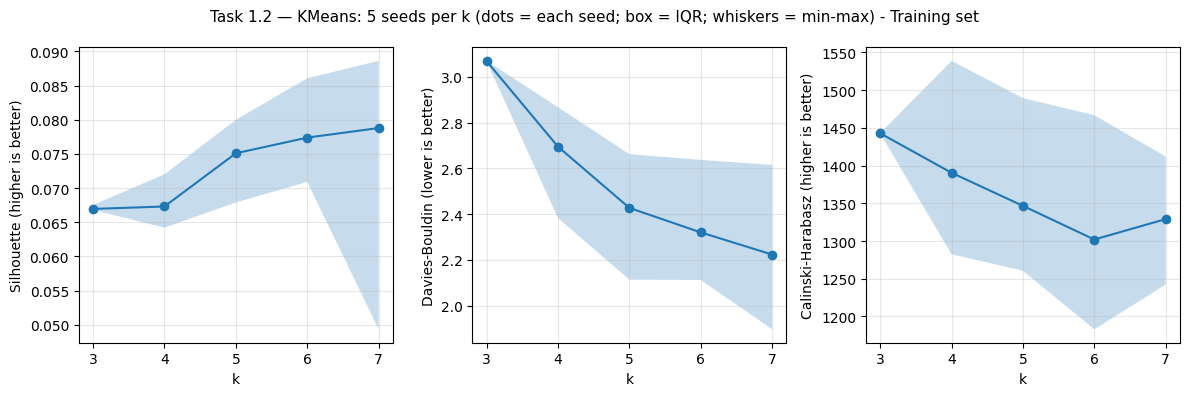

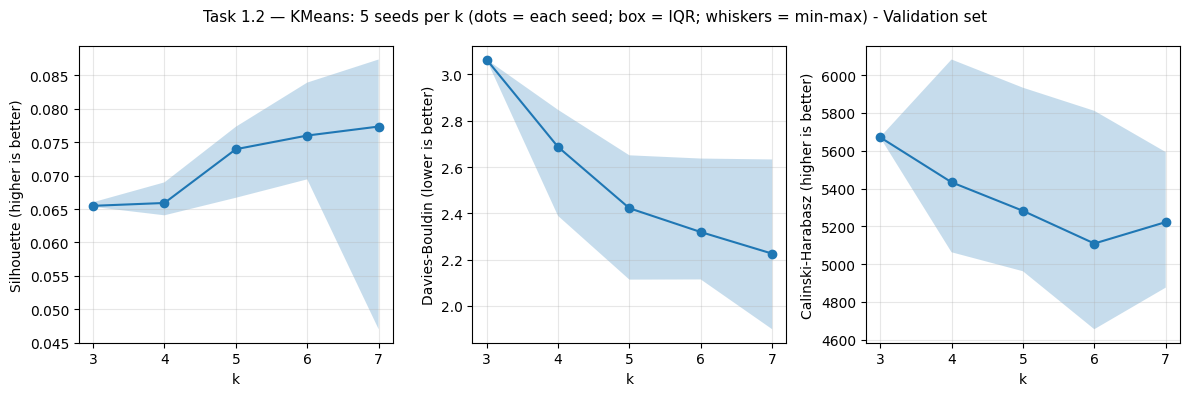

In [58]:
# Plot training metrics
plot_metric_spread(
    train_df_runs,
    metrics=['silhouette', 'davies_bouldin', 'calinski_harabasz'],
    metric_labels=[
        'Silhouette (higher is better)',
        'Davies-Bouldin (lower is better)',
        'Calinski-Harabasz (higher is better)',
    ],
    title='Task 1.2 — KMeans: 5 seeds per k (dots = each seed; box = IQR; whiskers = min-max) - Training set',
    filename='task1_2_clustering_metrics_train.png'
)

# Plot validation metrics
plot_metric_spread(
    val_df_runs,
    metrics=['silhouette', 'davies_bouldin', 'calinski_harabasz'],
    metric_labels=[
        'Silhouette (higher is better)',
        'Davies-Bouldin (lower is better)',
        'Calinski-Harabasz (higher is better)',
    ],
    title='Task 1.2 — KMeans: 5 seeds per k (dots = each seed; box = IQR; whiskers = min-max) - Validation set',
    filename='task1_2_clustering_metrics_val.png'
)

In [ ]:
# for seed in SEEDS:
#     ward_model = AgglomerativeClustering(n_clusters=k, linkage='ward')
#     ward_labels = ward_model.fit_predict(X_sample)
#     ward_s_score = silhouette_score(X_sample, ward_labels)
#     results.append({'clustering': 'Ward', 'k': k, 'seed': seed, 'silhouette': ward_s_score})
#     ward_db_score = davies_bouldin_score(X_sample, ward_labels)
#     results.append({'clustering': 'Ward', 'k': k, 'seed': seed, 'davies_bouldin': ward_db_score})
#     ward_ch_score = calinski_harabasz_score(X_sample, ward_labels)
#     results.append({'clustering': 'Ward', 'k': k, 'seed': seed, 'calinski_harabasz': ward_ch_score})
#     print(f'Ward k={k} seed={seed} -> silhouette={ward_s_score:.4f}, davies_bouldin={ward_db_score:.4f}, calinski_harabasz={ward_ch_score:.4f}')
